# Trabajo Práctico 1 - Grupo 02

### Ejercicio 4

Integrantes:
- Bermudez, Agustin
- Calderón, Tiago
- Gonzalez Pautaso, Mateo
- Moreyra, Santiago
- Nieves, Maylen

## Análisis y preprocesamiento

### Carga de datos
Para el desarrollo de este ejercicio se utilizan datos de características de audio de canciones disponibles en Spotify, con el objetivo de identificar agrupaciones naturales entre tracks a partir de sus atributos musicales.

#### Sobre el dataset

Los datos contienen información sobre 750 canciones de Spotify, con características de audio extraídas a través de la Spotify Web API. El archivo está en formato `.csv` y se carga usando el método específico para ello de pandas.

Cada fila representa una canción e incluye variables que describen propiedades acústicas y musicales como energía, danzabilidad, acústica, entre otras.

#### Descripción de variables
##### Variables cuantitativas (numéricas continuas)

- **acousticness:** Medida de confianza de si la canción es acústica (0.0–1.0)
- **danceability:** Qué tan adecuada es la canción para bailar, basado en tempo, ritmo y regularidad del beat (0.0–1.0)
- **duration:** Duración de la canción en milisegundos
- **energy:** Medida de intensidad y actividad perceptual de la canción (0.0–1.0)
- **instrumentalness:** Predice si la canción no contiene voces (0.0–1.0; valores cercanos a 1.0 indican mayor instrumentalidad)
- **liveness:** Detecta presencia de audiencia en vivo en la grabación (0.0–1.0)
loudness: Volumen general de la canción en decibeles (dB), típicamente entre -60 y 0
- **speechiness:** Detecta la presencia de palabras habladas en la canción (0.0–1.0)
- **tempo:** Tempo estimado en pulsaciones por minuto (BPM)
- **valence:** Positividad musical transmitida por la canción (0.0–1.0; valores altos suenan más alegres)

##### Variables cuantitativas discretas

- **time_signature:** Compás estimado de la canción (valores enteros, típicamente de 1 a 5)

##### Variables categóricas (excluidas del clustering)

- **key:** Tonalidad de la canción (valores enteros 0–11, donde cada número representa una nota musical). Se excluye porque la distancia numérica entre tonalidades no tiene significado para K-Means.
- **mode:** Modalidad de la escala (0 = menor, 1 = mayor). Se excluye por ser una variable nominal binaria sin orden real.

In [274]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

In [275]:
df = pd.read_csv('playlist_spotify.csv')

df.head(5)

,acousticness,danceability,duration,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,0.713,0.514,100125,0.521,0.816000,8,0.1120,-14.835,0,0.0444,119.879,4,0.143
1,0.192,0.714,207019,0.614,0.000000,4,0.2630,-6.935,1,0.0319,123.969,4,0.582
2,0.333,0.630,216200,0.455,0.000004,5,0.1270,-9.290,1,0.0292,139.931,4,0.199
3,0.601,0.810,136413,0.221,0.210000,5,0.1840,-11.005,1,0.0429,109.960,4,0.798
4,0.883,0.465,181440,0.459,0.000173,6,0.0692,-8.137,0,0.0351,90.807,4,0.288


In [276]:
df.describe().round(3)

,acousticness,danceability,duration,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
count,750.000,750.000,750.000,750.000,750.000,750.000,750.000,750.000,750.000,750.000,750.000,750.000,750.000
mean,0.357,0.596,220112.733,0.594,0.100,4.829,0.203,-8.509,0.741,0.099,120.406,3.903,0.497
std,0.338,0.172,65587.690,0.253,0.260,3.636,0.178,5.039,0.438,0.105,28.378,0.400,0.240
min,0.000,0.107,33840.000,0.009,0.000,0.000,0.024,-29.601,0.000,0.023,55.747,1.000,0.033
25%,0.037,0.480,185490.250,0.423,0.000,1.000,0.095,-10.174,0.000,0.036,98.998,4.000,0.297
50%,0.244,0.606,215108.500,0.632,0.000,5.000,0.129,-7.270,1.000,0.049,120.104,4.000,0.483
75%,0.679,0.716,244236.750,0.805,0.002,8.000,0.265,-5.098,1.000,0.113,138.075,4.000,0.685
max,0.994,0.986,675360.000,0.995,0.967,11.000,0.979,-0.533,1.000,0.721,204.162,5.000,0.975


In [277]:
print(df.dtypes)
print(f"\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

acousticness        float64
danceability        float64
duration              int64
energy              float64
instrumentalness    float64
key                   int64
liveness            float64
loudness            float64
mode                  int64
speechiness         float64
tempo               float64
time_signature        int64
valence             float64
dtype: object

Dimensiones: 750 filas x 13 columnas


## Análisis de valores faltantes

In [278]:
feature_cols = ['acousticness', 'danceability', 'duration', 'energy',
                'instrumentalness', 'liveness', 'loudness', 'speechiness',
                'tempo', 'time_signature', 'valence']

print('Valores nulos:')
print(df[feature_cols].isnull().sum())

Valores nulos:
acousticness        0
danceability        0
duration            0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64


Sin valores nulos. No se requiere imputacion.

## Análisis de valores atípicos

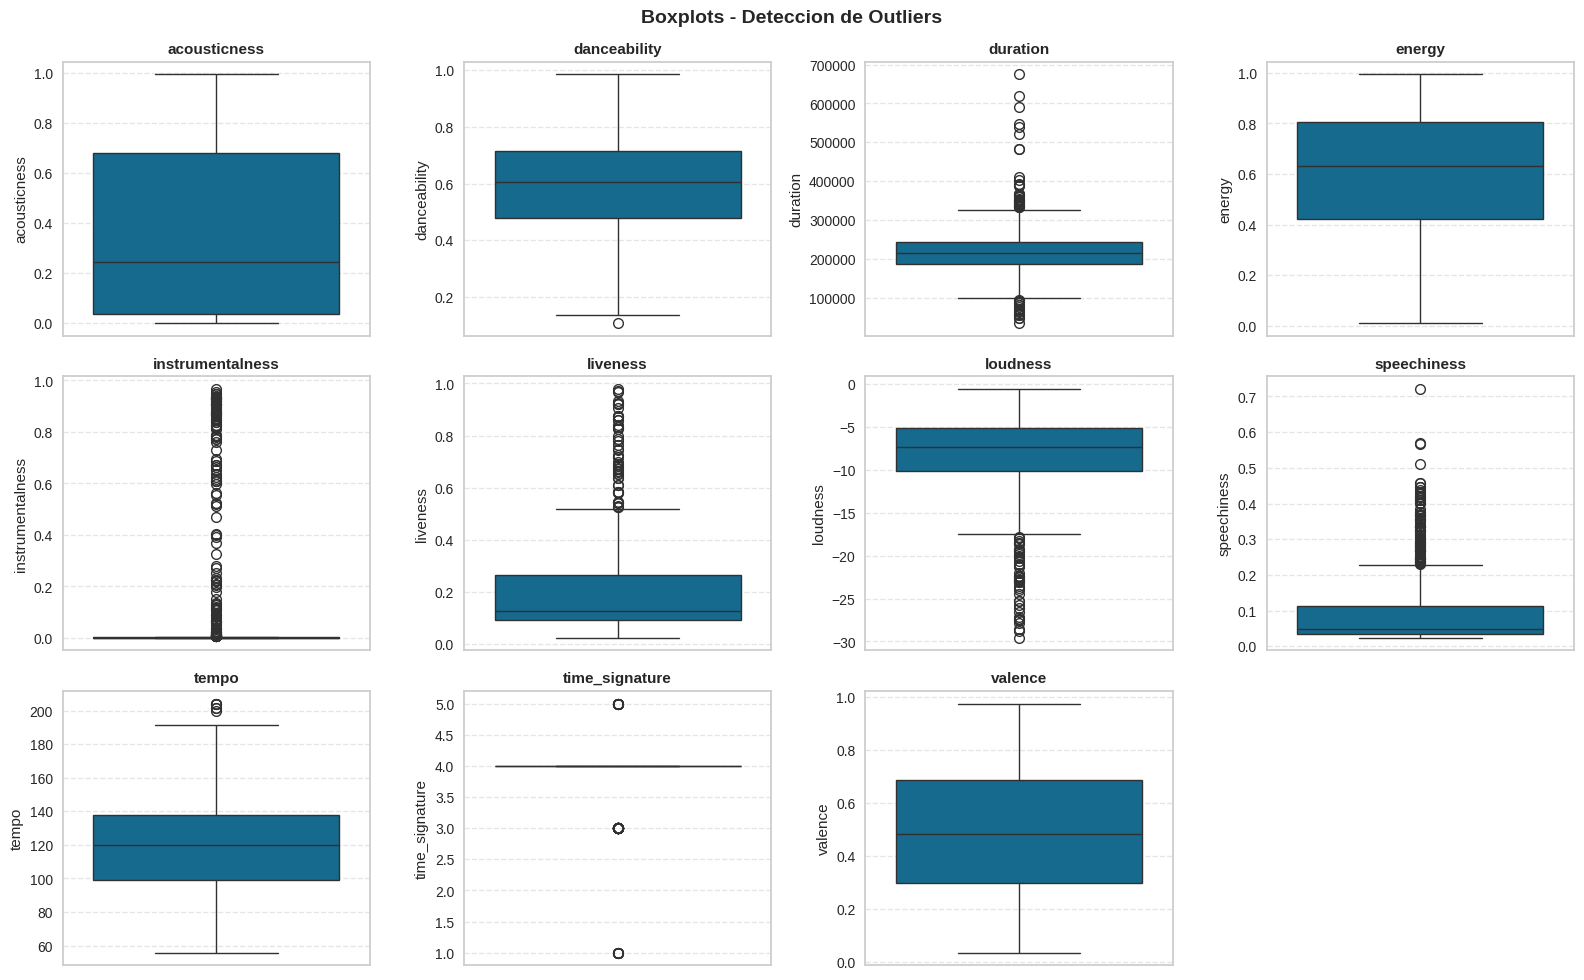

In [279]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
axes[-1].set_visible(False)
fig.suptitle('Boxplots - Deteccion de Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [280]:
print('Outliers por metodo IQR:')
for col in feature_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        print(f'- {col}: {n_out} outliers ({n_out/len(df)*100:.1f}%)')

Outliers por metodo IQR:
- danceability: 1 outliers (0.1%)
- duration: 53 outliers (7.1%)
- instrumentalness: 162 outliers (21.6%)
- liveness: 51 outliers (6.8%)
- loudness: 49 outliers (6.5%)
- speechiness: 96 outliers (12.8%)
- tempo: 7 outliers (0.9%)
- time_signature: 79 outliers (10.5%)


Se detectaron outliers principalmente en `instrumentalness` (21.6%), `speechiness` (12.8%) y `duration` (7.1%), entre otras.

Decidimos mantenerlos ya que no necesariamente son errores, sino que puede tratarse de canciones con características más pecularias, por ejemplo una canción que sea completamente instrumental o canciones muy largas.

Adicionalmente, como se trata de un problema de clustering los outliers permiten definir los grupos más diferenciados.

Lo que sí haremos para mitigar la influencia que podrían tener sobre K-Means es el escalado.

## Escalado

K-Means asigna cada punto al centroide más cercano usando distancia euclidiana, por lo que es sensible a la magnitud de las variables. En este dataset conviven variables acotadas entre 0 y 1 (como `energy` o `valence`) con otras de rangos mucho mayores como `duration` (del orden de los 200.000 ms) o `loudness` (-60 a 0 dB). Sin escalar, estas últimas dominarían el cálculo de distancias y harían irrelevantes al resto.

Se aplica `StandardScaler`, que transforma cada variable a media 0 y desvío estándar 1, garantizando que todas contribuyan por igual.

In [281]:
X = df[feature_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.head(5)

,acousticness,danceability,duration,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,valence
0,1.051530,-0.479513,-1.830645,-0.289129,2.755574,-0.514824,-1.256057,-0.521443,-0.018575,0.24344,-1.479699
1,-0.489072,0.683807,-0.199770,0.078268,-0.385931,0.335928,0.312609,-0.640895,0.125647,0.24344,0.353630
2,-0.072134,0.195213,-0.059696,-0.549862,-0.385917,-0.430312,-0.155012,-0.666697,0.688498,0.24344,-1.245835
3,0.720345,1.242201,-1.277002,-1.474280,0.422545,-0.109167,-0.495552,-0.535778,-0.368338,0.24344,1.255678
4,1.554221,-0.764526,-0.590027,-0.534060,-0.385265,-0.755964,0.073934,-0.610315,-1.043710,0.24344,-0.874157


## a. Tendencia al clustering

Para analizar la tendencia al clustering de nuestro dataset utilizaremos el índice de Hopkins H que indica:

- **H > 0.75:** fuerte evidencia de estructura de clusters (los algoritmos de clustering son adecuados).
- **H ≈ 0.5:** distribución aleatoria, sin clusters definidos.
- **H < 0.5:** indica regularidad o repulsión entre los puntos (poco común en datasets reales).

Como en cada ejecución samplea un subconjunto distinto de puntos del dataset, utilizaremos el promedio de 15 ejecuciones para que el valor sea más representativo.

In [282]:
def Hopkins(datos,*args):
    np.random.seed(42)
    n = datos.shape[0] # filas
    d = datos.shape[1] # columnas

    if not args:
        m = int(0.1 * n) # cantidad de puntos al azar (default)
    else:
        m = args[0] # cantidad de puntos al azar

    nbrs = NearestNeighbors(n_neighbors=1, algorithm='brute').fit(datos) # buscador de vecinos
    random.seed(42)
    rand_ind = random.sample(range(0, n, 1), m) # indices al azar

    ui = []
    wi = []
    for j in range(0, m):

        u_dist, _ = nbrs.kneighbors(
            np.random.uniform(np.min(datos, axis=0), np.max(datos, axis=0), size=(1, d)).reshape(1, -1),
            2, return_distance=True
        )

        ui.append(u_dist[0][1])

        w_dist, _ = nbrs.kneighbors(datos[rand_ind[j]].reshape(1, -1), 2, return_distance=True) # distancia a los puntos al azar

        wi.append(w_dist[0][1])


    H = sum(ui) / (sum(ui) + sum(wi))
    return H

H_scores = [Hopkins(X_scaled) for _ in range(15)]
H_mean = np.mean(H_scores)
print(f'Indice de Hopkins (promedio 15 ejecuciones): H = {H_mean:.4f}')

Indice de Hopkins (promedio 15 ejecuciones): H = 0.8226


### Conclusión

El índice de Hopkins nos retornó **0.8226** lo que indica una fuerte tendencia a clustering.

## b. Estimación de cantidad de grupos a formar

### Método del codo
Para determinar el K óptimo se utiliza el método del codo, que consiste en entrenar K-Means para distintos valores de K y graficar la inercia (WCSS, suma de distancias cuadráticas de cada punto a su centroide) en función de K.

A medida que K aumenta la inercia siempre disminuye, pero llega un punto donde la mejora se vuelve marginal. Ese quiebre en la curva, que visualmente recuerda a un codo, indica el K a partir del cual agregar más clusters no aporta mejora significativa.

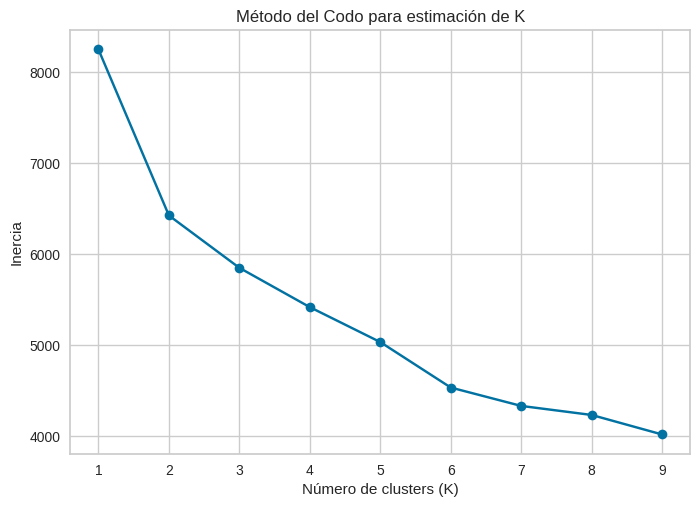

In [283]:
sse = []
K = range(1, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.plot(K, sse, marker='o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo para estimación de K')
plt.show()

Como podemos observar, la curva muestra un quiebre claro en **K=3**, a partir del cual la reducción de inercia se vuelve progresivamente menor. Esto sugiere que 3 es el número de clusters que mejor equilibra compacidad y simplicidad del modelo.

### Índice de Silhouette

Como método complementario se utiliza el índice de Silhouette, que evalúa la calidad del clustering midiendo para cada punto qué tan similar es a su propio cluster en comparación con los clusters vecinos.

El score promedio varía entre -1 y 1: valores cercanos a 1 indican clusters bien definidos y separados, valores cercanos a 0 indican superposición entre clusters, y valores negativos indican puntos posiblemente mal asignados.

A diferencia del método del codo que solo mide compacidad interna, el índice de Silhouette considera también la separación entre grupos, lo que lo convierte en una métrica más completa para elegir K.

Para 2 clusters, el índice de silueta es 0.2647
Para 3 clusters, el índice de silueta es 0.2046
Para 4 clusters, el índice de silueta es 0.1690
Para 5 clusters, el índice de silueta es 0.1417
Para 6 clusters, el índice de silueta es 0.1737
Para 7 clusters, el índice de silueta es 0.1797
Para 8 clusters, el índice de silueta es 0.1473
Para 9 clusters, el índice de silueta es 0.1511
Para 10 clusters, el índice de silueta es 0.1207

El número óptimo de clusters es: 2


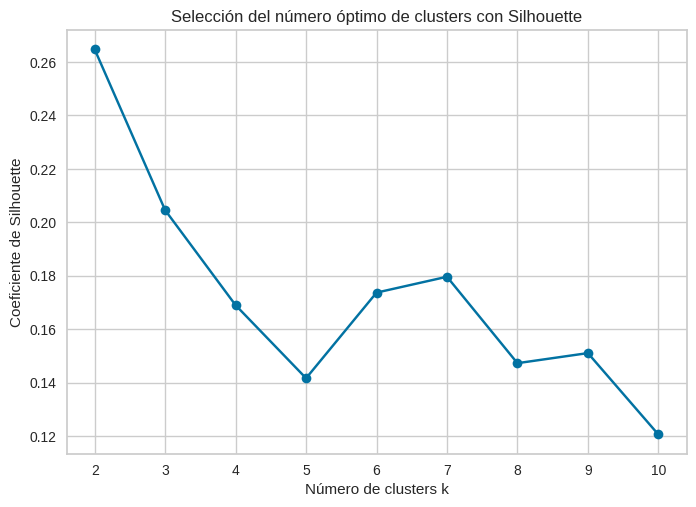

In [284]:
k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"Para {k} clusters, el índice de silueta es {score:.4f}")

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nEl número óptimo de clusters es: {optimal_k}")

plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel("Número de clusters k")
plt.ylabel("Coeficiente de Silhouette")
plt.title("Selección del número óptimo de clusters con Silhouette")
plt.xticks(np.arange(min(k_range), max(k_range)+1, 1))
plt.show()

El score más alto se obtiene para **K=2** (0.265), por lo que este método sugiere 2 como el número óptimo de clusters.

### Conclusión
El método del codo sugiere **K=3** y el índice de Silhouette sugiere **K=2**, con **K=3** obteniendo un score muy cercano (0.2046 vs 0.2647).

Dado que ambos métodos apuntan a valores similares pero no coinciden, se decide entrenar K-Means con ambos valores y comparar los resultados para determinar cuál ofrece una segmentación más interpretable.

## c. Análisis de Silhouette

El **Silhouette plot** muestra el coeficiente de cada cancion individualmente:

- Valores cercanos a +1: bien asignada, lejos de clusters vecinos
- Valores cercanos a 0: en la frontera entre clusters
- Valores negativos: posiblemente mal asignada

### Análisis con K = 2

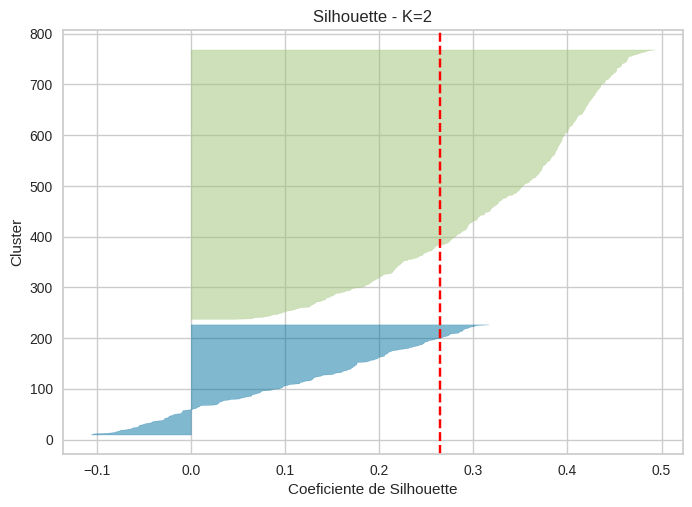

Cluster 0: n=218, score promedio=0.1153, positivos=168, negativos=50
Cluster 1: n=532, score promedio=0.3259, positivos=532, negativos=0


In [285]:
model = KMeans(2, random_state=42)
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')
visualizer.fit(X_scaled)
plt.title(f'Silhouette - K=2')
plt.xlabel('Coeficiente de Silhouette')
plt.ylabel('Cluster')
plt.show()

labels = model.labels_
sil_vals = silhouette_samples(X_scaled, labels)

for i in range(2):
    cv = sil_vals[labels == i]
    print(f"Cluster {i}: n={len(cv)}, score promedio={cv.mean():.4f}, positivos={( cv>0).sum()}, negativos={(cv<0).sum()}")

El Cluster 1 (532 canciones) es muy cohesivo, sin ningún punto negativo y con score promedio alto (0.33), lo que indica que ese grupo está bien definido y separado.

El Cluster 0 en cambio es más problemático: tiene 50 puntos negativos y un score promedio bajo (0.12), lo que sugiere que esas canciones no encajan claramente en ninguno de los dos grupos.

La partición en 2 es demasiado gruesa y fuerza canciones de perfiles distintos a convivir en el mismo cluster.

### Análisis con K = 3

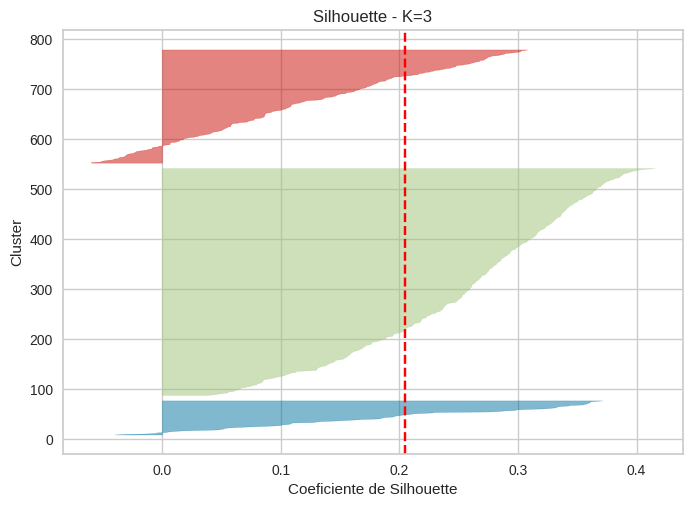

Cluster 0: n=69, score promedio=0.1837, positivos=64, negativos=5
Cluster 1: n=454, score promedio=0.2515, positivos=454, negativos=0
Cluster 2: n=227, score promedio=0.1170, positivos=192, negativos=35


In [286]:
model = KMeans(3, random_state=42)
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')
visualizer.fit(X_scaled)
plt.title(f'Silhouette - K=3')
plt.xlabel('Coeficiente de Silhouette')
plt.ylabel('Cluster')
plt.show()

labels = model.labels_
sil_vals = silhouette_samples(X_scaled, labels)

for i in range(3):
    cv = sil_vals[labels == i]
    print(f"Cluster {i}: n={len(cv)}, score promedio={cv.mean():.4f}, positivos={( cv>0).sum()}, negativos={(cv<0).sum()}")

Al dividir en 3 clusters la situación es más equilibrada.

El Cluster 1 sigue siendo el más cohesivo (454 canciones, 0 negativos, score 0.25), el Cluster 0 es pequeño (69 canciones) y relativamente compacto, y el Cluster 2 es el más heterogéneo con 35 negativos y el score más bajo (0.12).

### Conclusión

Aunque **K=2** tiene un score global mayor, su Cluster 0 concentra demasiada heterogeneidad. **K=3** distribuye mejor esa heterogeneidad y permite identificar un tercer perfil musical diferenciado, a costa de un score global levemente menor.

Por esto se opta por **K=3** como partición final.

## d. Análisis de grupos

Una vez definido **K=3** como partición final, se analiza el perfil de cada cluster
a partir de los centroides revertidos a escala original, complementado con
visualizaciones que permiten comparar las características de cada grupo.

In [287]:
df['cluster'] = labels

scaled_centroids = pd.DataFrame(model.cluster_centers_, columns=feature_cols)
centroids = pd.DataFrame(scaler.inverse_transform(scaled_centroids), columns=feature_cols)
centroids.index = [f'Cluster {i}' for i in range(3)]

print('Centroides por Cluster (escala original)')
centroids.round(3)

Centroides por Cluster (escala original)


,acousticness,danceability,duration,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,valence
Cluster 0,0.871,0.459,266691.478,0.217,0.742,0.121,-18.182,0.046,108.456,3.870,0.341
Cluster 1,0.139,0.662,215931.485,0.755,0.042,0.223,-5.901,0.123,124.528,4.000,0.573
Cluster 2,0.637,0.507,214316.934,0.386,0.021,0.189,-10.786,0.066,115.794,3.718,0.393


In [288]:
print(f'\nTamaño de clusters:')
print(df['cluster'].value_counts().sort_index())


Tamaño de clusters:
cluster
0     69
1    454
2    227
Name: count, dtype: int64


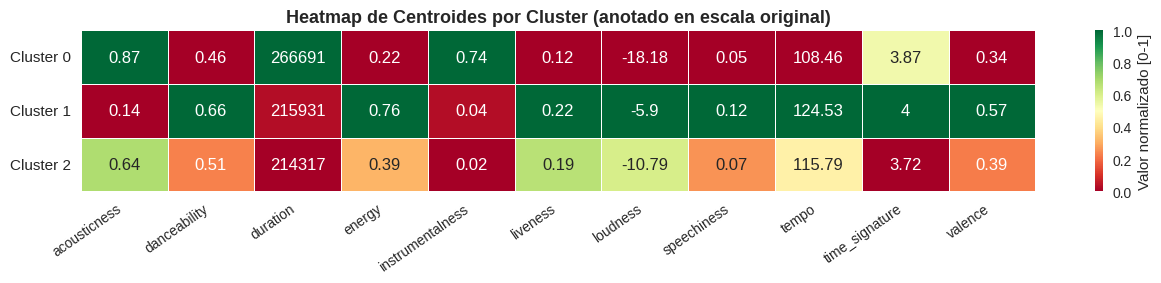

In [289]:
mm = MinMaxScaler()

centroids_norm = pd.DataFrame(
    mm.fit_transform(centroids),
    columns=feature_cols,
    index=centroids.index
)

plt.figure(figsize=(13, 3))
sns.heatmap(
    centroids_norm,
    annot=centroids.round(2),
    fmt='g',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Valor normalizado [0-1]'}
)
plt.title('Heatmap de Centroides por Cluster (anotado en escala original)',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

El heatmap muestra los centroides de cada cluster sobre todas las variables originales, donde el color refleja el valor normalizado entre 0 y 1 para hacer comparables variables de distintas escalas, mientras que los números anotados corresponden a los valores reales en escala original.

Se puede observar claramente que el **Cluster 0** domina en `acousticness` e `instrumentalness` y tiene los valores más bajos de `energy` y `loudness`, que podría indicar un perfil acústico o instrumental. El **Cluster 1** presenta los valores más altos de `energy`, `loudness` y `danceability`, lo que lo identifica como el cluster energético y bailable. El **Cluster 2** ocupa valores intermedios en la mayoría de las variables, es un perfil moderado y balanceado.

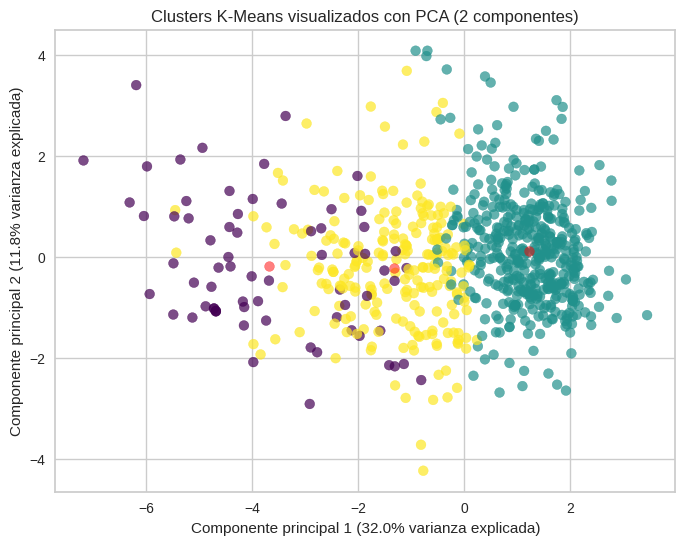

Varianza total explicada por PC1+PC2: 43.8%


In [290]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=50, cmap='viridis', alpha=0.7)

centers_pca = pca.transform(model.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', s=200, alpha=0.5, marker='.')

plt.xlabel(f'Componente principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza explicada)')
plt.ylabel(f'Componente principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza explicada)')
plt.title('Clusters K-Means visualizados con PCA (2 componentes)')
plt.show()

print(f'Varianza total explicada por PC1+PC2: {sum(pca.explained_variance_ratio_)*100:.1f}%')

Para poder visualizar los clusters formados, fue necesario investigar una alternativa al gráfico visto en clase, ya que en ese caso los datos ya eran bidimensionales y podían graficarse directamente. Con 11 features no es posible hacer eso, por lo que se optó por aplicar PCA, una técnica de reducción de dimensionalidad que transforma las variables originales en nuevas variables llamadas componentes principales, proyectando los datos a 2D para poder visualizarlos.

Es importante aclarar que el clustering se realizó sobre las 11 features originales y PCA se aplica únicamente con fines visuales. PC1 y PC2 explican en conjunto el 43.8% de la varianza total, por lo que el gráfico es una aproximación y la superposición visible entre clusters no implica que estén mal formados.

Aún así, se puede apreciar la estructura general, el cluster acústico/instrumental (violeta) se separa claramente hacia la izquierda a lo largo de PC1, el cluster energético/bailable (verde) se concentra hacia la derecha, y el cluster moderado (amarillo) queda en una posición intermedia, lo cual es consistente con los perfiles identificados en el heatmap de centroides.

### Interpretación y Perfil Musical de los Clusters

### Cluster 0 — Música Acústica e Instrumental

**Características clave:** `acousticness` muy alta (≈0.871),
`instrumentalness` dominante (≈0.742), `energy` muy baja (≈0.217),
`loudness` bajo (≈-18.182 dB), mayor duración promedio (≈261.000 ms).

**Perfil:** Canciones tranquilas, instrumentales y de larga duración.
Corresponde a **música clásica, ambient o folk instrumental**.
Es el cluster más pequeño pero el más fácil de separar,
confirmado por ser el de mayor score en el análisis de Silhouette.

### Cluster 1 — Música Energética y Bailable

**Características clave:** `energy` muy alta (≈0.755), `loudness` elevado (≈-5.901 dB),
`danceability` alta (≈0.662), `acousticness` muy baja (≈0.139).

**Perfil:** Canciones producidas digitalmente, con ritmos fuertes y alto volumen,
diseñadas para el movimiento. Baja instrumentalidad y presencia de voz prominente.
Prototipo de música **pop/dance/electrónica mainstream**.
Es el cluster más grande y el más cohesivo (0 valores negativos en Silhouette).

### Cluster 2 — Música Moderada y Balanceada

**Características clave:** Valores intermedios en casi todas las features.
`acousticness` moderada (≈0.637), `energy` media (≈0.386),
`loudness` moderado (≈-10.786 dB).

**Perfil:** El grupo más heterogéneo: canciones que no son ni extremadamente
enérgicas ni completamente acústicas. Abarca **pop alternativo, rock suave y baladas**.
Es el cluster con mayor cantidad de puntos negativos en el Silhouette,
lo que refleja su naturaleza de perfil intermedio.

### Resumen

K-Means con K=3 separa el dataset en tres arquetipos musicales bien diferenciados,
ordenados de mayor a menor energía:
**Energético/Bailable → Moderado/Balanceado → Acústico/Instrumental**.
El eje principal de separación es la combinación de `energy`, `acousticness`
e `instrumentalness`, que captura el espectro desde música producida
digitalmente hasta música acústica sin voz.

## Guardado de modelos y dataset procesado

In [291]:
import joblib

joblib.dump(model, 'TA047R_TP1_GRUPO02_EJ4_kmeans_k3.pkl')
print("Modelo guardado correctamente.")

# Dataset procesado
df.to_csv("TA047R_TP1_GRUPO02_EJ4_playlist_spotify_procesado.csv", index=False)

# Verificación
print("Archivos guardados:")
import os
archivos = [
    "TA047R_TP1_GRUPO02_EJ4_kmeans_k3.pkl",
    "TA047R_TP1_GRUPO02_EJ4_playlist_spotify_procesado.csv",
]
for f in archivos:
    size = os.path.getsize(f) / 1024
    print(f"  {f}  →  {size:.1f} KB")

Modelo guardado correctamente.
Archivos guardados:
  TA047R_TP1_GRUPO02_EJ4_kmeans_k3.pkl  →  3.9 KB
  TA047R_TP1_GRUPO02_EJ4_playlist_spotify_procesado.csv  →  53.8 KB
